# Proyecto Módulo 8 - Fundamentos de Deep Learning
## Clasificador Inteligente de Imágenes de Ropa
### Lección 1 - La red neuronal artificial

## Definición del problema

La empresa StyleNet necesita automatizar la clasificación de imágenes de ropa para reducir errores y tiempos de categorización manual. En esta primera etapa se desarrollará una red neuronal artificial densa aplicada a una tarea de clasificación binaria, utilizando imágenes de prendas de vestir.

## Objetivo de la lección

Comprender los elementos básicos de una red neuronal artificial e implementar un primer modelo funcional en Python. Para ello, se utilizará un subconjunto binario del dataset Fashion-MNIST, de modo que el problema sea más simple de interpretar antes de avanzar hacia modelos más complejos.

## Elementos clave de una red neuronal artificial

Una red neuronal artificial está compuesta por capas de neuronas conectadas entre sí. Cada conexión posee un peso, el cual se ajusta durante el entrenamiento para minimizar el error del modelo.

Los principales componentes que se analizarán en esta lección son:

- **Capas:** estructuras donde se transforman los datos de entrada.
- **Pesos:** parámetros que determinan la influencia de una neurona sobre otra.
- **Función de activación:** mecanismo que introduce no linealidad en la red.
- **Función de pérdida:** medida del error entre la predicción del modelo y el valor real.
- **Optimizador:** algoritmo que ajusta los pesos para reducir la pérdida.

## Enfoque de trabajo

Para esta lección se construirá una red neuronal densa simple con Keras, usando dos clases del dataset Fashion-MNIST. El objetivo no es aún obtener el mejor modelo final, sino comprender la lógica de funcionamiento de una red neuronal artificial básica.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

Path("../outputs").mkdir(parents=True, exist_ok=True)

TensorFlow version: 2.21.0


In [2]:
# =========================================================
# 1) CARGA DEL DATASET FASHION-MNIST
# =========================================================
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

print("===== DIMENSIONES ORIGINALES =====")
print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_test:", x_test.shape)
print("y_test:", y_test.shape)

===== DIMENSIONES ORIGINALES =====
x_train: (60000, 28, 28)
y_train: (60000,)
x_test: (10000, 28, 28)
y_test: (10000,)


## Subconjunto binario utilizado

Para simplificar la primera implementación, se seleccionarán solo dos clases del dataset:

- **0 = T-shirt/top**
- **1 = Trouser**

De este modo, la salida del modelo será binaria y podrá interpretarse fácilmente mediante una función de activación sigmoide y una función de pérdida de entropía cruzada binaria.

In [3]:
# =========================================================
# 2) FILTRADO A CLASIFICACIÓN BINARIA
# Clase 0: T-shirt/top
# Clase 1: Trouser
# =========================================================
clases_objetivo = [0, 1]

mask_train = np.isin(y_train, clases_objetivo)
mask_test = np.isin(y_test, clases_objetivo)

x_train_bin = x_train[mask_train]
y_train_bin = y_train[mask_train]

x_test_bin = x_test[mask_test]
y_test_bin = y_test[mask_test]

# Normalización a escala [0, 1]
x_train_bin = x_train_bin.astype("float32") / 255.0
x_test_bin = x_test_bin.astype("float32") / 255.0

# Aplanado de imágenes 28x28 -> 784
x_train_bin = x_train_bin.reshape(-1, 28 * 28)
x_test_bin = x_test_bin.reshape(-1, 28 * 28)

# Mezcla y separación de validación
rng = np.random.default_rng(13094978)
indices = rng.permutation(len(x_train_bin))

x_train_bin = x_train_bin[indices]
y_train_bin = y_train_bin[indices]

val_size = int(len(x_train_bin) * 0.2)

x_val_bin = x_train_bin[:val_size]
y_val_bin = y_train_bin[:val_size]

x_train_final = x_train_bin[val_size:]
y_train_final = y_train_bin[val_size:]

print("===== DIMENSIONES BINARIAS =====")
print("x_train_final:", x_train_final.shape)
print("y_train_final:", y_train_final.shape)
print("x_val_bin:", x_val_bin.shape)
print("y_val_bin:", y_val_bin.shape)
print("x_test_bin:", x_test_bin.shape)
print("y_test_bin:", y_test_bin.shape)

===== DIMENSIONES BINARIAS =====
x_train_final: (9600, 784)
y_train_final: (9600,)
x_val_bin: (2400, 784)
y_val_bin: (2400,)
x_test_bin: (2000, 784)
y_test_bin: (2000,)


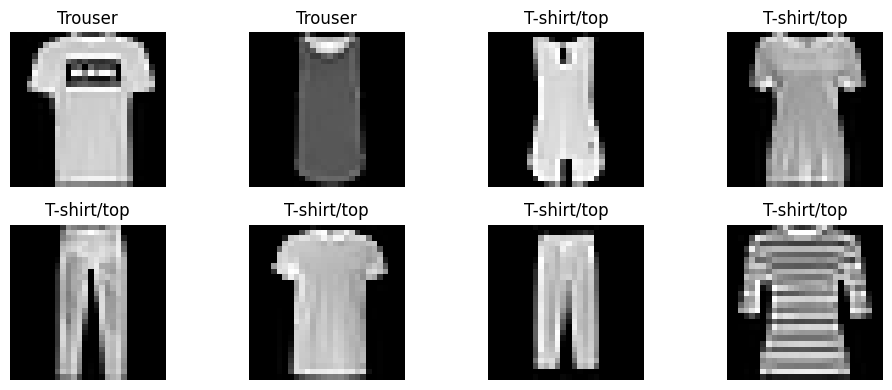

In [4]:
# =========================================================
# 3) VISUALIZACIÓN DE EJEMPLOS
# =========================================================
plt.figure(figsize=(10, 4))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(x_train[mask_train][i], cmap="gray")
    plt.title(class_names[y_train_bin[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Arquitectura de la red neuronal densa

La arquitectura propuesta para esta primera red es la siguiente:

- **Capa de entrada:** 784 variables, correspondientes a los píxeles de la imagen aplanada.
- **Capa oculta densa:** 128 neuronas con activación ReLU.
- **Capa Dropout:** regularización para reducir sobreajuste.
- **Capa de salida:** 1 neurona con activación sigmoide.

### Justificación de componentes

- **ReLU** se utiliza en la capa oculta porque favorece el aprendizaje eficiente y introduce no linealidad.
- **Sigmoide** se utiliza en la salida porque el problema es binario y necesitamos una probabilidad entre 0 y 1.
- **Binary Crossentropy** se usa como función de pérdida porque corresponde a clasificación binaria.
- **Adam** se utiliza como optimizador por su buen desempeño general en redes neuronales.

In [5]:
# =========================================================
# 4) DEFINICIÓN DEL MODELO
# =========================================================
modelo_denso_binario = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.20),
    layers.Dense(1, activation="sigmoid")
])

modelo_denso_binario.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("===== RESUMEN DEL MODELO =====")
modelo_denso_binario.summary()

===== RESUMEN DEL MODELO =====


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,609 (393.00 KB)

 Trainable params: 100,609 (393.00 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# =========================================================
# 5) ENTRENAMIENTO
# =========================================================
history = modelo_denso_binario.fit(
    x_train_final,
    y_train_final,
    validation_data=(x_val_bin, y_val_bin),
    epochs=10,
    batch_size=64,
    verbose=1
)

Epoch 1/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9729 - loss: 0.0808 - val_accuracy: 0.9829 - val_loss: 0.0597
Epoch 2/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9855 - loss: 0.0420 - val_accuracy: 0.9854 - val_loss: 0.0585
Epoch 3/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9904 - loss: 0.0323 - val_accuracy: 0.9887 - val_loss: 0.0468
Epoch 4/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9900 - loss: 0.0281 - val_accuracy: 0.9883 - val_loss: 0.0401
Epoch 5/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9924 - loss: 0.0235 - val_accuracy: 0.9892 - val_loss: 0.0474
Epoch 6/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9929 - loss: 0.0201 - val_accuracy: 0.9887 - val_loss: 0.0390
Epoch 7/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9943 - loss: 0.0179 - val_accuracy: 0.9900 - val_loss: 0.0350
Epoch 8/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9949 - loss: 0.0167 - val_accuracy: 0.

In [7]:
# =========================================================
# 6) EVALUACIÓN FINAL
# =========================================================
loss_test, acc_test = modelo_denso_binario.evaluate(x_test_bin, y_test_bin, verbose=0)

print("===== RESULTADOS EN TEST =====")
print(f"Loss test: {loss_test:.4f}")
print(f"Accuracy test: {acc_test:.4f}")

===== RESULTADOS EN TEST =====
Loss test: 0.0329
Accuracy test: 0.9910


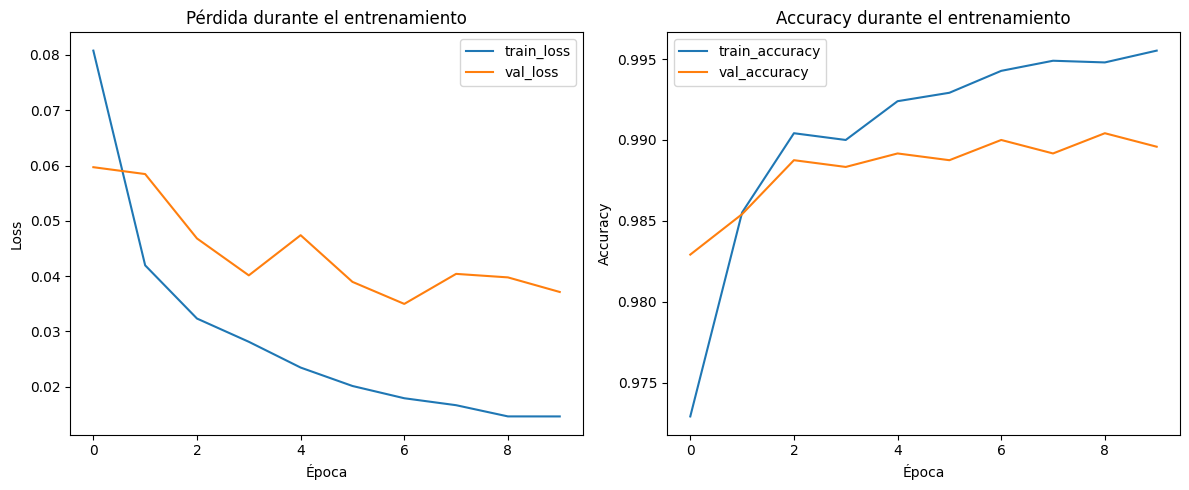

In [8]:
# =========================================================
# 7) CURVAS DE ENTRENAMIENTO
# =========================================================
hist_df = pd.DataFrame(history.history)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(hist_df["loss"], label="train_loss")
plt.plot(hist_df["val_loss"], label="val_loss")
plt.title("Pérdida durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_df["accuracy"], label="train_accuracy")
plt.plot(hist_df["val_accuracy"], label="val_accuracy")
plt.title("Accuracy durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.savefig("../outputs/leccion1_curvas_entrenamiento_binario.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
# =========================================================
# 8) PESOS Y SESGOS DE LA PRIMERA CAPA
# =========================================================
pesos_capa1, bias_capa1 = modelo_denso_binario.layers[0].get_weights()

print("===== INFORMACIÓN DE PESOS =====")
print("Forma de la matriz de pesos de la primera capa:", pesos_capa1.shape)
print("Forma del vector de sesgos de la primera capa:", bias_capa1.shape)

===== INFORMACIÓN DE PESOS =====
Forma de la matriz de pesos de la primera capa: (784, 128)
Forma del vector de sesgos de la primera capa: (128,)


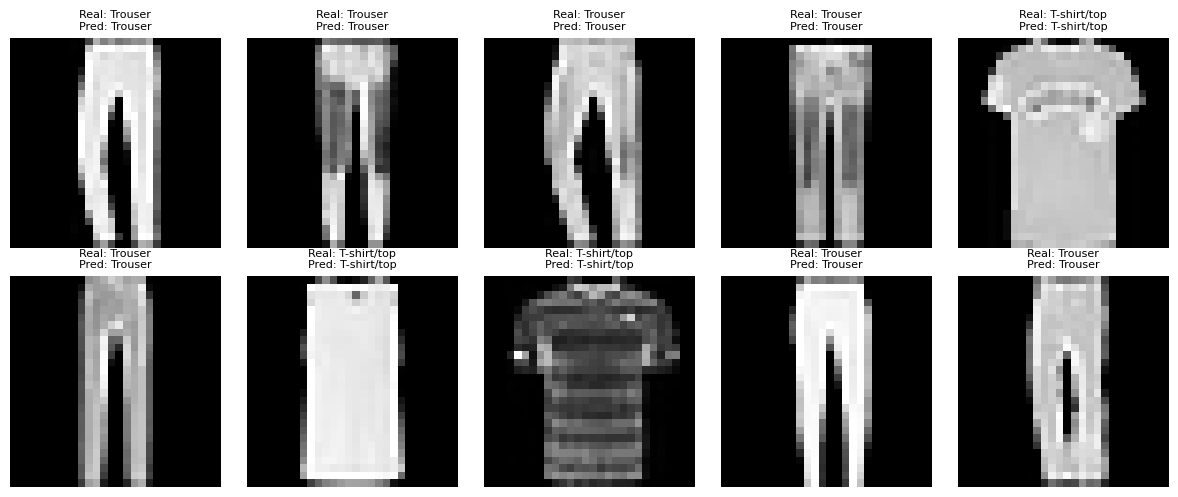

In [10]:
# =========================================================
# 9) PREDICCIONES DE EJEMPLO
# =========================================================
probabilidades = modelo_denso_binario.predict(x_test_bin[:10], verbose=0)
predicciones = (probabilidades >= 0.5).astype(int).flatten()

plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[mask_test][i], cmap="gray")
    etiqueta_real = class_names[y_test_bin[i]]
    etiqueta_pred = class_names[predicciones[i]]
    plt.title(f"Real: {etiqueta_real}\nPred: {etiqueta_pred}", fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.savefig("../outputs/leccion1_predicciones_binarias.png", dpi=300, bbox_inches="tight")
plt.show()

### Hallazgos de la Lección 1

En esta etapa se implementó una red neuronal artificial densa para resolver una tarea de clasificación binaria sobre imágenes de ropa. El modelo permitió identificar de manera práctica los componentes esenciales de una red neuronal: capas, pesos, activaciones, función de pérdida y optimizador. Asimismo, se observó el comportamiento del entrenamiento mediante curvas de pérdida y accuracy, y se evaluó el desempeño sobre un conjunto de prueba independiente.

Esta primera implementación constituye una base conceptual y práctica para avanzar hacia arquitecturas más adecuadas para clasificación de imágenes, particularmente redes convolutivas, las cuales se analizarán en las siguientes etapas del proyecto.

## Lección 2 - Deep Learning

### Objetivo de esta etapa

En esta etapa se analizarán las principales arquitecturas de Deep Learning aplicadas a clasificación de imágenes, con el fin de justificar qué tipo de red neuronal resulta más adecuada para el problema planteado. Asimismo, se seleccionará formalmente el framework de desarrollo que se utilizará en el proyecto y se preparará el dataset completo para las siguientes etapas de entrenamiento.

## Arquitectura óptima para clasificación de imágenes

En problemas de clasificación de imágenes, las arquitecturas más adecuadas suelen ser las **redes neuronales convolutivas (CNN)**. Esto se debe a que las imágenes poseen una estructura espacial en la que la cercanía entre píxeles contiene información relevante sobre bordes, formas, texturas y patrones visuales.

Una red densa tradicional trata cada píxel como una entrada independiente, lo que provoca pérdida de estructura espacial y un crecimiento importante en la cantidad de parámetros. En cambio, una CNN utiliza filtros o kernels que recorren la imagen para detectar patrones locales, reutilizando pesos y reduciendo la complejidad del modelo.

## Justificación: red densa vs red convolutiva

### Red densa
- Aplana la imagen y pierde parte de la estructura espacial.
- Es útil como aproximación inicial o baseline.
- Tiene mayor cantidad de parámetros cuando la entrada es grande.
- Puede funcionar bien en tareas simples, pero suele ser menos eficiente para imágenes complejas.

### Red convolutiva
- Conserva la estructura bidimensional de la imagen.
- Aprende patrones locales como bordes y formas.
- Usa menos parámetros que una red totalmente conectada equivalente.
- Suele lograr mejor generalización y mayor precisión en clasificación de imágenes.

## Framework seleccionado

Para este proyecto se utilizará **Keras con TensorFlow** como framework principal. La elección se justifica porque permite construir, entrenar y evaluar redes neuronales de forma clara y eficiente, integrando fácilmente datasets como Fashion-MNIST y facilitando la comparación entre redes densas y convolutivas dentro de un notebook reproducible.

En consecuencia, la estrategia del proyecto será la siguiente:

- utilizar una **red densa** como modelo inicial multiclase;
- rediseñar posteriormente la solución mediante una **CNN**;
- comparar ambos enfoques con base en accuracy, pérdida y capacidad de generalización.

In [11]:
# =========================================================
# 1) PREPARACIÓN DEL DATASET COMPLETO FASHION-MNIST
# =========================================================
(x_train_full, y_train_full), (x_test_full, y_test_full) = keras.datasets.fashion_mnist.load_data()

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Normalización
x_train_full = x_train_full.astype("float32") / 255.0
x_test_full = x_test_full.astype("float32") / 255.0

# Separación manual de validación
rng = np.random.default_rng(13094978)
indices = rng.permutation(len(x_train_full))

x_train_full = x_train_full[indices]
y_train_full = y_train_full[indices]

val_size = int(len(x_train_full) * 0.2)

x_val_full = x_train_full[:val_size]
y_val_full = y_train_full[:val_size]

x_train_multiclase = x_train_full[val_size:]
y_train_multiclase = y_train_full[val_size:]

print("===== DIMENSIONES MULTICLASE =====")
print("x_train_multiclase:", x_train_multiclase.shape)
print("y_train_multiclase:", y_train_multiclase.shape)
print("x_val_full:", x_val_full.shape)
print("y_val_full:", y_val_full.shape)
print("x_test_full:", x_test_full.shape)
print("y_test_full:", y_test_full.shape)

===== DIMENSIONES MULTICLASE =====
x_train_multiclase: (48000, 28, 28)
y_train_multiclase: (48000,)
x_val_full: (12000, 28, 28)
y_val_full: (12000,)
x_test_full: (10000, 28, 28)
y_test_full: (10000,)


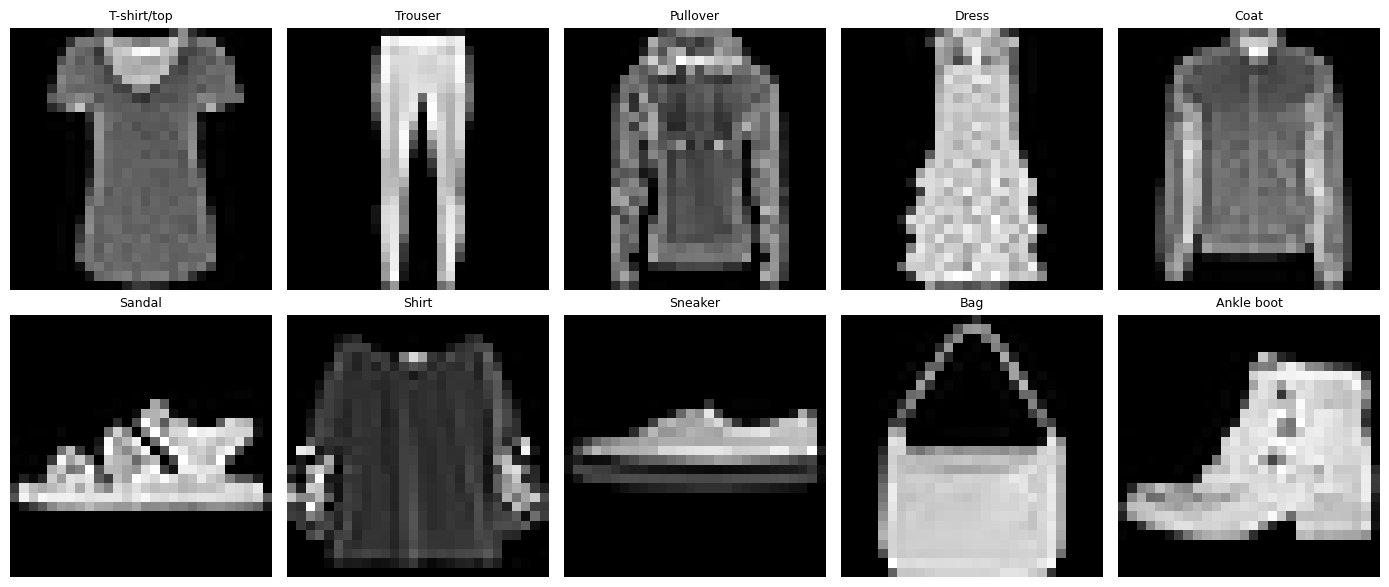

In [12]:
# =========================================================
# 2) VISUALIZACIÓN DE UNA IMAGEN POR CLASE
# =========================================================
plt.figure(figsize=(14, 6))

for clase in range(10):
    idx = np.where(y_train_multiclase == clase)[0][0]
    plt.subplot(2, 5, clase + 1)
    plt.imshow(x_train_multiclase[idx], cmap="gray")
    plt.title(class_names[clase], fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.savefig("../outputs/leccion2_ejemplos_por_clase.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
# =========================================================
# 3) COMPARACIÓN ESTRUCTURAL: RED DENSA VS CNN
# =========================================================
# Modelo denso multiclase
modelo_denso_multiclase = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.20),
    layers.Dense(10, activation="softmax")
])

# Modelo CNN multiclase
modelo_cnn_multiclase = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.20),
    layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.20),
    layers.Dense(10, activation="softmax")
])

print("===== RESUMEN RED DENSA MULTICLASE =====")
modelo_denso_multiclase.summary()

print("\n===== RESUMEN RED CNN MULTICLASE =====")
modelo_cnn_multiclase.summary()

===== RESUMEN RED DENSA MULTICLASE =====


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

...

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

### Hallazgos de la Lección 2

En esta etapa se justificó que la arquitectura más adecuada para clasificación de imágenes es una red neuronal convolutiva, debido a su capacidad para preservar la estructura espacial de la imagen y aprender patrones locales de forma más eficiente que una red densa tradicional. Asimismo, se seleccionó Keras como framework de trabajo por su facilidad de implementación, integración con TensorFlow y compatibilidad con Fashion-MNIST.

Finalmente, se preparó el dataset completo de 10 clases y se definieron dos arquitecturas base: una red densa multiclase y una CNN multiclase. Estas servirán como referencia directa para las siguientes etapas del proyecto, en las cuales se entrenarán, validarán y compararán ambos enfoques.

## Lección 3 - Implementación de redes neuronales en Python

### Objetivo de esta etapa

En esta etapa se implementará un modelo funcional de red neuronal densa para clasificar las 10 categorías del dataset Fashion-MNIST. Además, se evaluarán diferentes configuraciones de hiperparámetros y se aplicarán técnicas de regularización y optimización para mejorar el desempeño del modelo y controlar el sobreajuste.

### Estrategia de modelado

Se utilizará una red neuronal densa multiclase como baseline formal del problema completo. Para comparar configuraciones, se entrenarán dos variantes del modelo con distinta cantidad de neuronas, tasa de dropout y batch size. La selección del mejor modelo se realizará en función del desempeño observado sobre el conjunto de validación.

In [14]:
# =========================================================
# 1) PREPARACIÓN DE DATOS PARA RED DENSA MULTICLASE
# =========================================================
# Aplanado para red densa
x_train_dense = x_train_multiclase.reshape(-1, 28 * 28)
x_val_dense = x_val_full.reshape(-1, 28 * 28)
x_test_dense = x_test_full.reshape(-1, 28 * 28)

print("===== DIMENSIONES PARA RED DENSA =====")
print("x_train_dense:", x_train_dense.shape)
print("x_val_dense:", x_val_dense.shape)
print("x_test_dense:", x_test_dense.shape)
print("y_train_multiclase:", y_train_multiclase.shape)
print("y_val_full:", y_val_full.shape)
print("y_test_full:", y_test_full.shape)

===== DIMENSIONES PARA RED DENSA =====
x_train_dense: (48000, 784)
x_val_dense: (12000, 784)
x_test_dense: (10000, 784)
y_train_multiclase: (48000,)
y_val_full: (12000,)
y_test_full: (10000,)


In [15]:
# =========================================================
# 2) FUNCIÓN PARA CREAR MODELOS DENSOS MULTICLASE
# =========================================================
def crear_modelo_denso(unidades=128, dropout_rate=0.20, learning_rate=0.001):
    modelo = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(unidades, activation="relu"),
        layers.Dropout(dropout_rate),
        layers.Dense(10, activation="softmax")
    ])

    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return modelo

In [16]:
# =========================================================
# 3) CONFIGURACIONES A COMPARAR
# =========================================================
configuraciones = [
    {
        "nombre": "Modelo_A",
        "unidades": 128,
        "dropout_rate": 0.20,
        "learning_rate": 0.001,
        "batch_size": 64,
        "epochs": 15
    },
    {
        "nombre": "Modelo_B",
        "unidades": 256,
        "dropout_rate": 0.30,
        "learning_rate": 0.001,
        "batch_size": 128,
        "epochs": 15
    }
]

resultados_experimentos = []
histories = {}
modelos_entrenados = {}

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [17]:
# =========================================================
# 4) ENTRENAMIENTO DE CONFIGURACIONES
# =========================================================
for cfg in configuraciones:
    print(f"\n===== ENTRENANDO {cfg['nombre']} =====")

    modelo = crear_modelo_denso(
        unidades=cfg["unidades"],
        dropout_rate=cfg["dropout_rate"],
        learning_rate=cfg["learning_rate"]
    )

    history = modelo.fit(
        x_train_dense,
        y_train_multiclase,
        validation_data=(x_val_dense, y_val_full),
        epochs=cfg["epochs"],
        batch_size=cfg["batch_size"],
        callbacks=[early_stopping],
        verbose=1
    )

    val_loss, val_acc = modelo.evaluate(x_val_dense, y_val_full, verbose=0)
    test_loss, test_acc = modelo.evaluate(x_test_dense, y_test_full, verbose=0)

    resultados_experimentos.append({
        "modelo": cfg["nombre"],
        "unidades": cfg["unidades"],
        "dropout": cfg["dropout_rate"],
        "learning_rate": cfg["learning_rate"],
        "batch_size": cfg["batch_size"],
        "val_loss": val_loss,
        "val_accuracy": val_acc,
        "test_loss": test_loss,
        "test_accuracy": test_acc
    })

    histories[cfg["nombre"]] = history.history
    modelos_entrenados[cfg["nombre"]] = modelo


===== ENTRENANDO Modelo_A =====
Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7971 - loss: 0.5773 - val_accuracy: 0.8481 - val_loss: 0.4257
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8522 - loss: 0.4165 - val_accuracy: 0.8658 - val_loss: 0.3744
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8620 - loss: 0.3833 - val_accuracy: 0.8650 - val_loss: 0.3684
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8713 - loss: 0.3571 - val_accuracy: 0.8758 - val_loss: 0.3390
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8766 - loss: 0.3380 - val_accuracy: 0.8773 - val_loss: 0.3336
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8814 - loss: 0.3263 - val_accuracy: 0.8789 - val_loss: 0.3279
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8826 - loss: 0.3178 - val_accuracy: 0.8783 - val_loss: 0.3242
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8878 

In [18]:
# =========================================================
# 5) TABLA COMPARATIVA DE HIPERPARÁMETROS
# =========================================================
df_resultados_dense = pd.DataFrame(resultados_experimentos)
df_resultados_dense = df_resultados_dense.sort_values(
    by=["val_accuracy", "test_accuracy"],
    ascending=False
).reset_index(drop=True)

print("===== RESULTADOS DE LOS EXPERIMENTOS =====")
display(df_resultados_dense.round(4))

mejor_nombre = df_resultados_dense.iloc[0]["modelo"]
mejor_modelo_denso = modelos_entrenados[mejor_nombre]

print(f"\nMejor modelo denso seleccionado: {mejor_nombre}")

===== RESULTADOS DE LOS EXPERIMENTOS =====


,modelo,unidades,dropout,learning_rate,batch_size,val_loss,val_accuracy,test_loss,test_accuracy
0,Modelo_A,128,0.2,0.001,64,0.2940,0.8913,0.3253,0.8823
1,Modelo_B,256,0.3,0.001,128,0.4566,0.8397,0.4738,0.8315



Mejor modelo denso seleccionado: Modelo_A


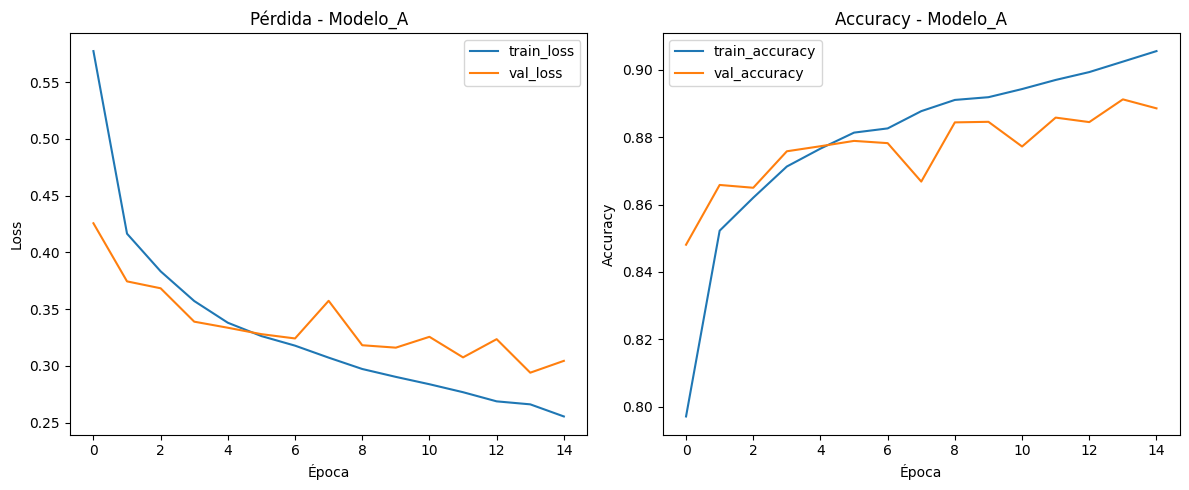

In [19]:
# =========================================================
# 6) CURVAS DE ENTRENAMIENTO DEL MEJOR MODELO
# =========================================================
hist_mejor = pd.DataFrame(histories[mejor_nombre])

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(hist_mejor["loss"], label="train_loss")
plt.plot(hist_mejor["val_loss"], label="val_loss")
plt.title(f"Pérdida - {mejor_nombre}")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_mejor["accuracy"], label="train_accuracy")
plt.plot(hist_mejor["val_accuracy"], label="val_accuracy")
plt.title(f"Accuracy - {mejor_nombre}")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.savefig("../outputs/leccion3_curvas_mejor_modelo_denso.png", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
# =========================================================
# 7) EVALUACIÓN FINAL DEL MEJOR MODELO EN TEST
# =========================================================
test_loss_final, test_acc_final = mejor_modelo_denso.evaluate(x_test_dense, y_test_full, verbose=0)

print("===== RESULTADOS FINALES EN TEST =====")
print(f"Modelo seleccionado: {mejor_nombre}")
print(f"Loss test: {test_loss_final:.4f}")
print(f"Accuracy test: {test_acc_final:.4f}")

===== RESULTADOS FINALES EN TEST =====
Modelo seleccionado: Modelo_A
Loss test: 0.3253
Accuracy test: 0.8823


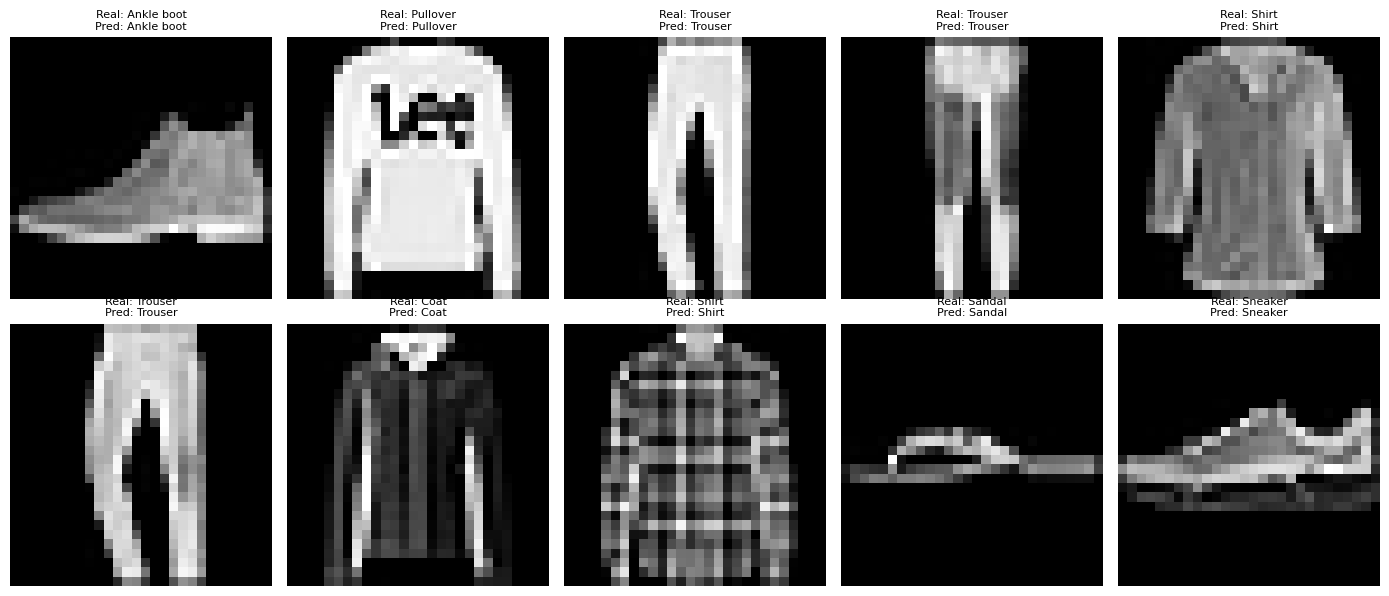

In [21]:
# =========================================================
# 8) PREDICCIONES DE EJEMPLO
# =========================================================
pred_probs = mejor_modelo_denso.predict(x_test_dense[:10], verbose=0)
pred_classes = np.argmax(pred_probs, axis=1)

plt.figure(figsize=(14, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test_full[i], cmap="gray")
    real = class_names[y_test_full[i]]
    pred = class_names[pred_classes[i]]
    plt.title(f"Real: {real}\nPred: {pred}", fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.savefig("../outputs/leccion3_predicciones_multiclase_denso.png", dpi=300, bbox_inches="tight")
plt.show()

### Hallazgos de la Lección 3

En esta etapa se implementó y entrenó una red neuronal densa multiclase sobre el dataset completo Fashion-MNIST. Se compararon distintas configuraciones de hiperparámetros, observando el efecto de la cantidad de neuronas, la tasa de dropout y el tamaño de batch sobre el desempeño del modelo. Además, se aplicaron técnicas de optimización y regularización mediante Adam, Dropout y EarlyStopping.

El resultado obtenido permite contar con un baseline multiclase funcional y bien documentado, que servirá como punto de comparación directo frente a la red convolutiva de la siguiente etapa.

## Lección 4 - Redes neuronales convolutivas

### Objetivo de esta etapa

En esta etapa se implementará una red neuronal convolutiva para clasificar imágenes del dataset Fashion-MNIST y se comparará su desempeño con el modelo denso multiclase desarrollado en la etapa anterior. El objetivo es evaluar si una arquitectura que preserve la estructura espacial de la imagen mejora la capacidad predictiva del sistema.

Además, se generarán predicciones visuales tanto sobre imágenes del conjunto de prueba como sobre imágenes externas cargadas manualmente, con el fin de aproximar el modelo a un escenario de uso más realista.

In [22]:
from pathlib import Path
from PIL import Image, ImageOps
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Path("../external_images").mkdir(parents=True, exist_ok=True)
Path("../outputs").mkdir(parents=True, exist_ok=True)

In [23]:
# =========================================================
# 1) PREPARACIÓN DE DATOS PARA CNN
# =========================================================
x_train_cnn = x_train_multiclase.reshape(-1, 28, 28, 1)
x_val_cnn = x_val_full.reshape(-1, 28, 28, 1)
x_test_cnn = x_test_full.reshape(-1, 28, 28, 1)

print("===== DIMENSIONES PARA CNN =====")
print("x_train_cnn:", x_train_cnn.shape)
print("x_val_cnn:", x_val_cnn.shape)
print("x_test_cnn:", x_test_cnn.shape)
print("y_train_multiclase:", y_train_multiclase.shape)
print("y_val_full:", y_val_full.shape)
print("y_test_full:", y_test_full.shape)

===== DIMENSIONES PARA CNN =====
x_train_cnn: (48000, 28, 28, 1)
x_val_cnn: (12000, 28, 28, 1)
x_test_cnn: (10000, 28, 28, 1)
y_train_multiclase: (48000,)
y_val_full: (12000,)
y_test_full: (10000,)


In [24]:
# =========================================================
# 2) DEFINICIÓN DEL MODELO CNN
# =========================================================
modelo_cnn = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.20),

    layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.20),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.20),
    layers.Dense(10, activation="softmax")
])

modelo_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("===== RESUMEN DEL MODELO CNN =====")
modelo_cnn.summary()

===== RESUMEN DEL MODELO CNN =====


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# =========================================================
# 3) ENTRENAMIENTO CNN
# =========================================================
early_stopping_cnn = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_cnn = modelo_cnn.fit(
    x_train_cnn,
    y_train_multiclase,
    validation_data=(x_val_cnn, y_val_full),
    epochs=15,
    batch_size=128,
    callbacks=[early_stopping_cnn],
    verbose=1
)

Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.7244 - loss: 0.7448 - val_accuracy: 0.8346 - val_loss: 0.4598
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.8259 - loss: 0.4749 - val_accuracy: 0.8594 - val_loss: 0.3818
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - accuracy: 0.8495 - loss: 0.4116 - val_accuracy: 0.8701 - val_loss: 0.3478
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.8625 - loss: 0.3809 - val_accuracy: 0.8775 - val_loss: 0.3315
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - accuracy: 0.8700 - loss: 0.3576 - val_accuracy: 0.8881 - val_loss: 0.3056
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.8787 - loss: 0.3355 - val_accuracy: 0.8916 - val_loss: 0.2940
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - accuracy: 0.8816 - loss: 0.3190 - val_accuracy: 0.8977 - val_loss: 0.2783
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.8888 - loss: 0.3049 - 

In [26]:
# =========================================================
# 4) EVALUACIÓN FINAL CNN
# =========================================================
cnn_val_loss, cnn_val_acc = modelo_cnn.evaluate(x_val_cnn, y_val_full, verbose=0)
cnn_test_loss, cnn_test_acc = modelo_cnn.evaluate(x_test_cnn, y_test_full, verbose=0)

# Mejor modelo denso ya definido en Lección 3
dense_test_loss, dense_test_acc = mejor_modelo_denso.evaluate(x_test_dense, y_test_full, verbose=0)

comparacion_modelos_dl = pd.DataFrame([
    ["Red densa multiclase", dense_test_loss, dense_test_acc],
    ["CNN multiclase", cnn_test_loss, cnn_test_acc]
], columns=["modelo", "test_loss", "test_accuracy"]).sort_values(
    by="test_accuracy", ascending=False
).reset_index(drop=True)

print("===== COMPARACIÓN DENSO VS CNN =====")
display(comparacion_modelos_dl.round(4))

print("\n===== RESULTADOS CNN =====")
print(f"Loss validación CNN: {cnn_val_loss:.4f}")
print(f"Accuracy validación CNN: {cnn_val_acc:.4f}")
print(f"Loss test CNN: {cnn_test_loss:.4f}")
print(f"Accuracy test CNN: {cnn_test_acc:.4f}")

===== COMPARACIÓN DENSO VS CNN =====


,modelo,test_loss,test_accuracy
0,CNN multiclase,0.2502,0.9095
1,Red densa multiclase,0.3253,0.8823



===== RESULTADOS CNN =====
Loss validación CNN: 0.2380
Accuracy validación CNN: 0.9095
Loss test CNN: 0.2502
Accuracy test CNN: 0.9095


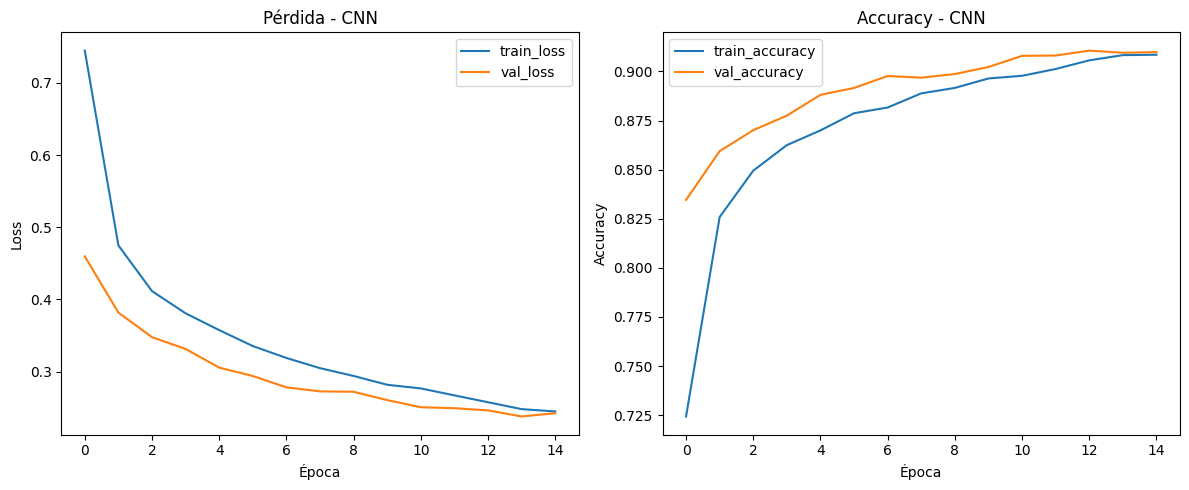

In [27]:
# =========================================================
# 5) CURVAS DE ENTRENAMIENTO CNN
# =========================================================
hist_cnn = pd.DataFrame(history_cnn.history)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(hist_cnn["loss"], label="train_loss")
plt.plot(hist_cnn["val_loss"], label="val_loss")
plt.title("Pérdida - CNN")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_cnn["accuracy"], label="train_accuracy")
plt.plot(hist_cnn["val_accuracy"], label="val_accuracy")
plt.title("Accuracy - CNN")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.savefig("../outputs/leccion4_curvas_cnn.png", dpi=300, bbox_inches="tight")
plt.show()

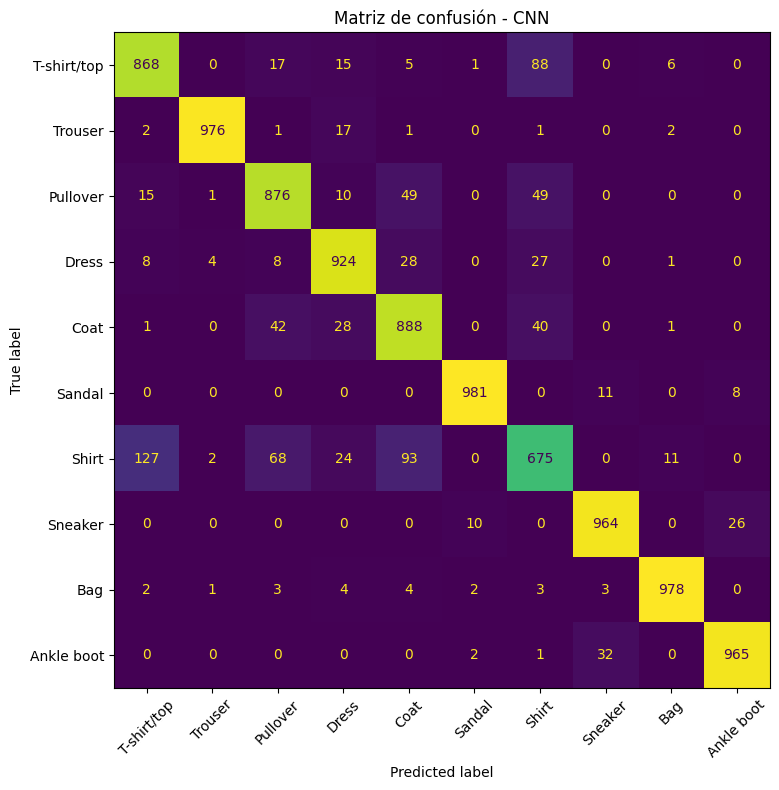

In [28]:
# =========================================================
# 6) MATRIZ DE CONFUSIÓN CNN
# =========================================================
pred_probs_cnn = modelo_cnn.predict(x_test_cnn, verbose=0)
pred_classes_cnn = np.argmax(pred_probs_cnn, axis=1)

cm = confusion_matrix(y_test_full, pred_classes_cnn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Matriz de confusión - CNN")
plt.tight_layout()
plt.savefig("../outputs/leccion4_matriz_confusion_cnn.png", dpi=300, bbox_inches="tight")
plt.show()

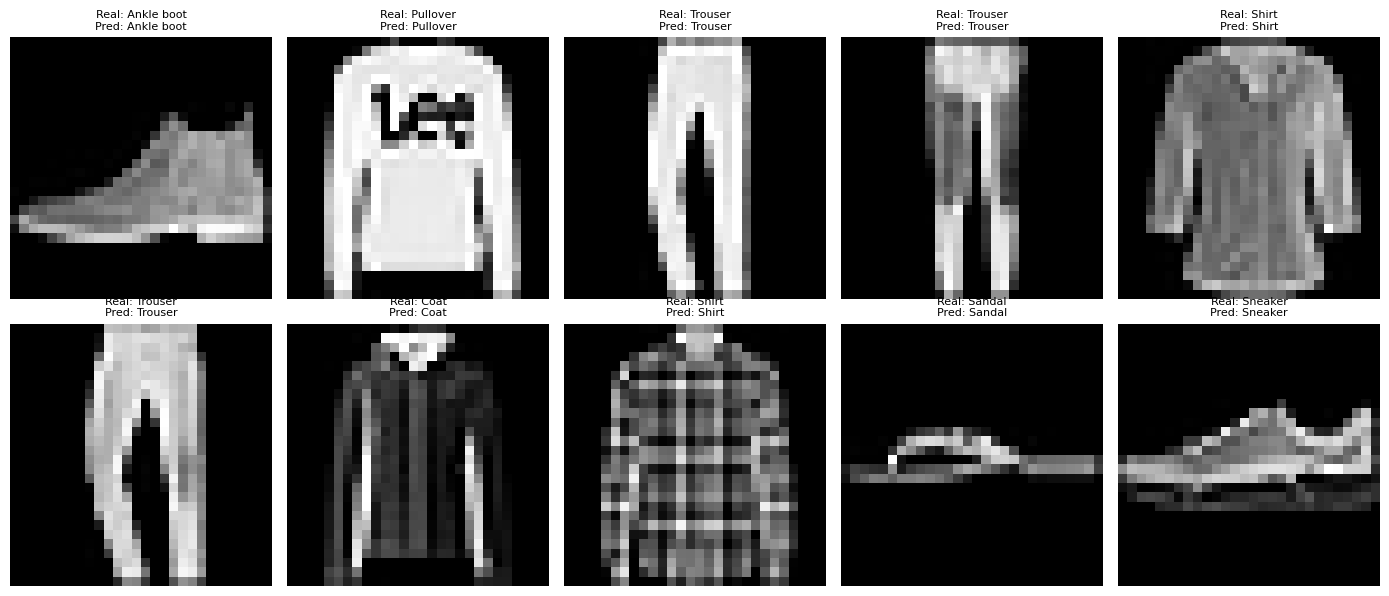

In [29]:
# =========================================================
# 7) PREDICCIONES VISUALES SOBRE TEST
# =========================================================
plt.figure(figsize=(14, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test_full[i], cmap="gray")
    real = class_names[y_test_full[i]]
    pred = class_names[pred_classes_cnn[i]]
    plt.title(f"Real: {real}\nPred: {pred}", fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.savefig("../outputs/leccion4_predicciones_cnn_test.png", dpi=300, bbox_inches="tight")
plt.show()

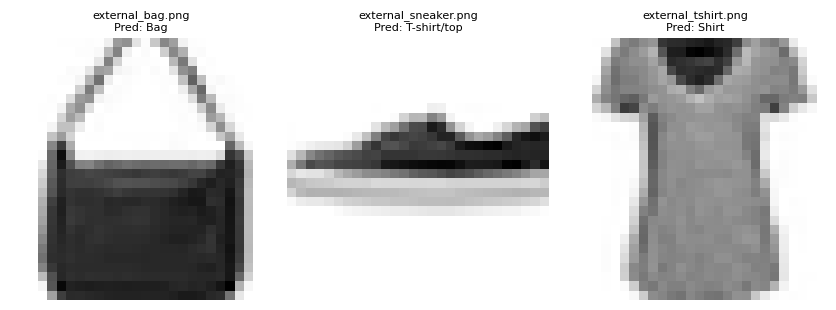

In [30]:
# =========================================================
# 8) PREDICCIONES SOBRE IMÁGENES EXTERNAS
# Guarda imágenes en ../external_images/
# =========================================================
rutas_imagenes = sorted(list(Path("../external_images").glob("*")))

if len(rutas_imagenes) == 0:
    print("No se encontraron imágenes externas en ../external_images/")
    print("Cuando quieras usar esta sección, guarda allí imágenes .png, .jpg o .jpeg.")
else:
    imagenes_procesadas = []
    nombres_archivos = []

    for ruta in rutas_imagenes:
        try:
            img = Image.open(ruta).convert("L")
            img = ImageOps.fit(img, (28, 28))
            img = ImageOps.invert(img)  # útil si la imagen tiene fondo blanco
            img_array = np.array(img).astype("float32") / 255.0
            imagenes_procesadas.append(img_array)
            nombres_archivos.append(ruta.name)
        except Exception as e:
            print(f"No se pudo procesar {ruta.name}: {e}")

    if len(imagenes_procesadas) > 0:
        X_ext = np.array(imagenes_procesadas).reshape(-1, 28, 28, 1)
        pred_ext_probs = modelo_cnn.predict(X_ext, verbose=0)
        pred_ext_classes = np.argmax(pred_ext_probs, axis=1)

        plt.figure(figsize=(14, 6))

        for i in range(len(imagenes_procesadas)):
            plt.subplot(max(1, (len(imagenes_procesadas)+4)//5), 5, i + 1)
            plt.imshow(imagenes_procesadas[i], cmap="gray")
            pred = class_names[pred_ext_classes[i]]
            plt.title(f"{nombres_archivos[i]}\nPred: {pred}", fontsize=8)
            plt.axis("off")

        plt.tight_layout()
        plt.savefig("../outputs/leccion4_predicciones_imagenes_externas.png", dpi=300, bbox_inches="tight")
        plt.show()

### Hallazgos de la Lección 4

En esta etapa se implementó una red neuronal convolutiva para clasificar imágenes del dataset Fashion-MNIST y se comparó su desempeño frente al modelo denso multiclase utilizado como baseline. La CNN permitió preservar la estructura espacial de la imagen mediante capas convolutivas y de pooling, lo que teóricamente favorece la detección de patrones visuales más complejos.

La comparación final entre ambos enfoques permitirá justificar si la arquitectura convolutiva mejora efectivamente la capacidad predictiva del sistema. Además, se dejaron implementadas predicciones visuales tanto sobre imágenes del conjunto de prueba como sobre imágenes externas cargadas manualmente, acercando el proyecto a un escenario de aplicación real.